# Step 1: Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# SciPy is a free, open-source Python library used for scientific, mathematical, and technical computing.

from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster

%matplotlib inline

# Step 2: Load Dataset

In [5]:
df = pd.read_csv("Mall_Customers.csv")

print("Dataset Shape :", df.shape)

df.head()

Dataset Shape : (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Step 3: Dataset Information

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# Step 4: Check Missing Values

In [7]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Step 5: Statistical Summary

In [9]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Step 6: Select Features for Clustering

In [12]:
X = df.iloc[:, [3,4]]

X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Step 7: Scatter Plot of Raw Data

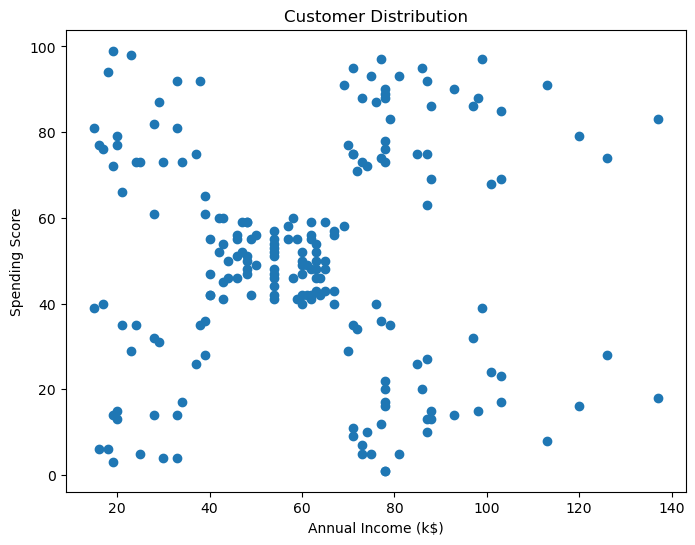

In [14]:
plt.figure(figsize = (8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1]
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")

plt.title("Customer Distribution")

plt.show()

# Step 8: Create Dendrogram

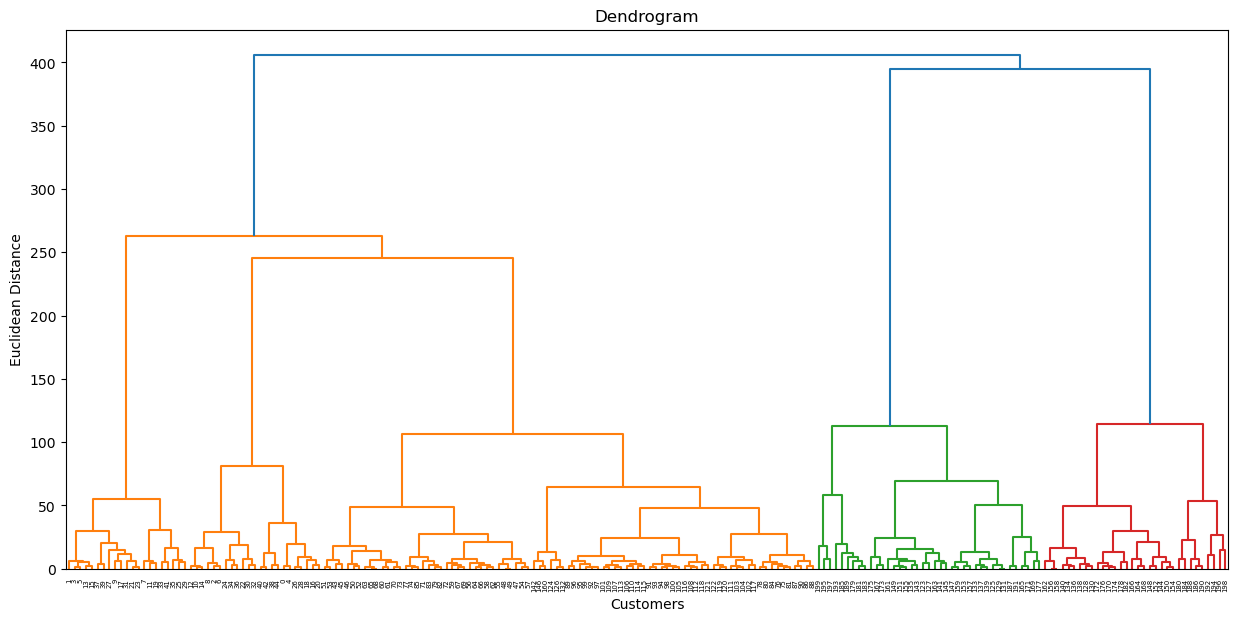

In [17]:
plt.figure(figsize = (15,7))

dendrogram(
    linkage(X, method = 'ward')
)

plt.title("Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Euclidean Distance")

plt.show()

In [ ]:
Understanding Dendrogram :

=> A dendrogram helps determine the optimal number of clusters.

=> Choose the longest vertical distance that doesn't cross horizontal lines.

=> For Mall Customers Dataset:

Usually:

Optimal Clusters = 5

# Step 9: Create Clusters

In [19]:
clusters = fcluster(
    linkage(X, method = 'ward'),
    t = 5,
    criterion = 'maxclust'
)

print(clusters)

[2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2 1 2
 1 2 1 2 1 2 3 2 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3 3
 3 3 3 3 3 3 3 3 3 3 3 3 4 3 4 3 4 5 4 5 4 3 4 5 4 5 4 5 4 5 4 3 4 5 4 3 4
 5 4 5 4 5 4 5 4 5 4 5 4 3 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4 5
 4 5 4 5 4 5 4 5 4 5 4 5 4 5 4]


# Step 10: Add Cluster Labels

In [20]:
df["Cluster"] = clusters

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,1
2,3,Female,20,16,6,2
3,4,Female,23,16,77,1
4,5,Female,31,17,40,2


# Step 11: Cluster Counts

In [21]:
df["Cluster"].value_counts()

3    85
4    39
5    32
2    23
1    21
Name: Cluster, dtype: int64

# Step 12: Visualize Clusters

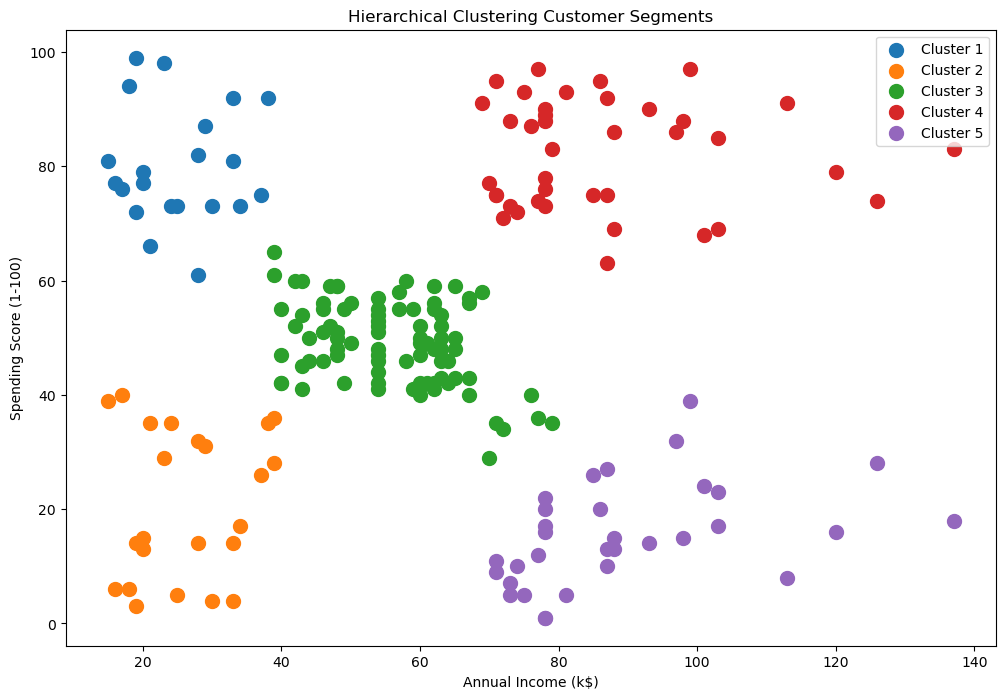

In [23]:
plt.figure(figsize = (12,8))

plt.scatter(
    X[clusters == 1]["Annual Income (k$)"],
    X[clusters == 1]["Spending Score (1-100)"],
    s = 100,
    label = "Cluster 1"
)

plt.scatter(
    X[clusters == 2]["Annual Income (k$)"],
    X[clusters == 2]["Spending Score (1-100)"],
    s = 100,
    label = "Cluster 2"
)

plt.scatter(
    X[clusters == 3]["Annual Income (k$)"],
    X[clusters == 3]["Spending Score (1-100)"],
    s = 100,
    label = "Cluster 3"
)

plt.scatter(
    X[clusters == 4]["Annual Income (k$)"],
    X[clusters == 4]["Spending Score (1-100)"],
    s = 100,
    label = "Cluster 4"
)

plt.scatter(
    X[clusters == 5]["Annual Income (k$)"],
    X[clusters == 5]["Spending Score (1-100)"],
    s = 100,
    label = "Cluster 5"
)

plt.title("Hierarchical Clustering Customer Segments")

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.legend()

plt.show()

# Step 13: Cluster Analysis

In [24]:
cluster_summary = df.groupby("Cluster").mean(numeric_only = True)

print(cluster_summary)

         CustomerID        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                                   
1         22.000000  25.333333           25.095238               80.047619
2         23.000000  45.217391           26.304348               20.913043
3         87.894118  42.482353           55.811765               49.129412
4        162.000000  32.692308           86.538462               82.128205
5        166.250000  41.000000           89.406250               15.593750


# Step 14: Cluster Centers

In [26]:
df.groupby("Cluster")[["Annual Income (k$)",
                       "Spending Score (1-100)",
                       "Age"]].mean()

,Annual Income (k$),Spending Score (1-100),Age
Cluster,,,
1,25.095238,80.047619,25.333333
2,26.304348,20.913043,45.217391
3,55.811765,49.129412,42.482353
4,86.538462,82.128205,32.692308
5,89.406250,15.593750,41.000000


# Advanced Visualization (Beautiful Cluster Plot)

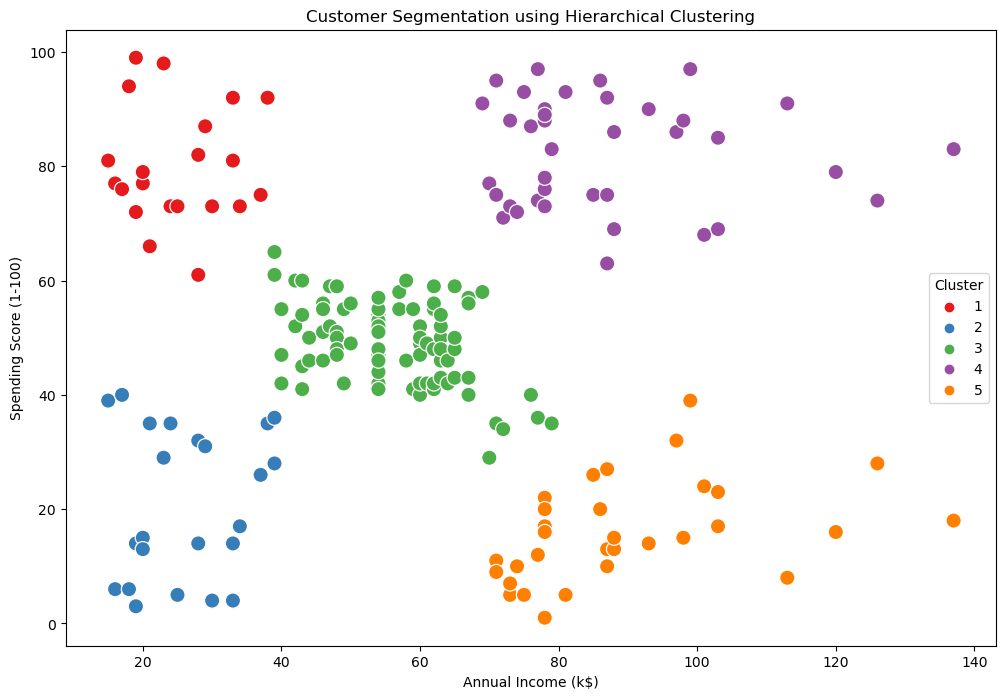

In [29]:
plt.figure(figsize = (12,8))

sns.scatterplot(
    data = df,
    x = "Annual Income (k$)",
    y = "Spending Score (1-100)",
    hue = "Cluster",
    palette = "Set1",
    s = 120
)

plt.title("Customer Segmentation using Hierarchical Clustering")

plt.show()

# Complete Hierarchical Clustering Workflow

# Hierarchical Clustering vs K-Means